In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def flops_gru(T, C, f, d):
    return T * (3*(C*f*d + d**2) + 3*d**2)

def flops_gat_global(C, d):
    return C*C*d

def flops_vmd(T):
    return T*np.log2(T)

def flops_mgs(n_g_list, w_g_list):
    return sum(n*w*np.log2(w) for n,w in zip(n_g_list, w_g_list))

def flops_gat_local(n_g_list, C, d):
    return sum(n*C*C*d for n in n_g_list)

def flops_cascade(N, K):
    return N*K*np.log2(N)

# Bizim küçük kurulumumuz
C, T, d, f = 3, 200, 8, 1
n_g_list = [19, 9, 4]     # τ=20,40,80 için pencere sayıları
w_g_list = [20, 40, 80]
N, K = 280, 100            # cascade forest için örnek/ağaç sayısı

results = {
    "GRU (global)": flops_gru(T,C,f,d),
    "GAT (global)": flops_gat_global(C,d),
    "VMD": flops_vmd(T),
    "MGS": flops_mgs(n_g_list, w_g_list),
    "GAT (local)": flops_gat_local(n_g_list, C, d),
    "Cascade Forest": flops_cascade(N,K),
}
for name, val in results.items():
    print(f"{name}: {val:,.0f} FLOPs")

GRU (global): 91,200 FLOPs
GAT (global): 72 FLOPs
VMD: 1,529 FLOPs
MGS: 5,581 FLOPs
GAT (local): 2,304 FLOPs
Cascade Forest: 227,620 FLOPs


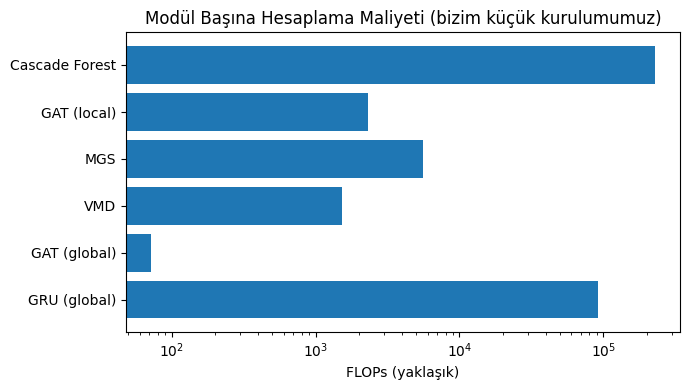

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
names = list(results.keys())
values = list(results.values())
ax.barh(names, values, color='tab:blue')
ax.set_xlabel("FLOPs (yaklaşık)")
ax.set_title("Modül Başına Hesaplama Maliyeti (bizim küçük kurulumumuz)")
ax.set_xscale('log')
plt.tight_layout(); plt.show()

In [ ]:
!pip install vmdpy -q

import torch
import torch.nn.functional as F

# Basitleştirilmiş GRU adımı simülasyonu
def dummy_gru_step_loop(T, C, d):
    h = torch.zeros(C, d)
    Wr = torch.randn(d, d)
    for t in range(T):
        a_t = torch.randn(C, d)
        h = torch.tanh(a_t @ Wr + h)
    return h

start = time.time()
_ = dummy_gru_step_loop(T, C, d)
t_gru = time.time() - start

start = time.time()
from vmdpy import VMD
_ = VMD(np.random.randn(T), 2000, 0.0, 4, 0, 1, 1e-6)
t_vmd = time.time() - start

print(f"GRU benzeri döngü süresi: {t_gru*1000:.2f} ms")
print(f"VMD süresi: {t_vmd*1000:.2f} ms")

GRU benzeri döngü süresi: 2.96 ms
VMD süresi: 33.73 ms


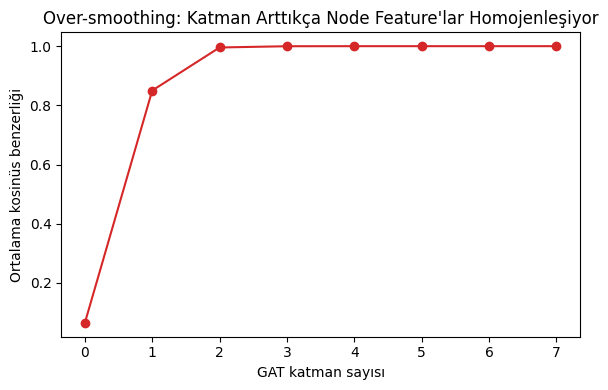

In [ ]:
def gat_step(X, A, w):
    C = X.shape[0]
    Z = torch.full((C,C), float('-inf'))
    for v in range(C):
        for u in range(C):
            if A[v,u] > 0:
                Z[v,u] = F.leaky_relu(torch.dot(w, torch.cat([X[v],X[u]])))
    alpha = torch.nan_to_num(F.softmax(Z, dim=1))
    H = torch.zeros_like(X)
    for v in range(C):
        neigh = [u for u in range(C) if A[v,u]>0]
        if neigh:
            H[v] = sum(alpha[v,u]*X[u] for u in neigh)
    return torch.tanh(H)   # residual YOK -- saf, derin GAT yığını gibi

def avg_cosine_similarity(X):
    Xn = F.normalize(X, dim=1)
    sim = Xn @ Xn.T
    C = X.shape[0]
    mask = ~torch.eye(C, dtype=bool)
    return sim[mask].mean().item()

C_test = 6
A_full = torch.ones(C_test, C_test) - torch.eye(C_test)   # tam bağlı graph
X = torch.randn(C_test, 8)
w = torch.randn(16)

sims = [avg_cosine_similarity(X)]
for layer in range(7):
    X = gat_step(X, A_full, w)
    sims.append(avg_cosine_similarity(X))

plt.figure(figsize=(6,4))
plt.plot(range(len(sims)), sims, 'o-', color='tab:red')
plt.xlabel("GAT katman sayısı")
plt.ylabel("Ortalama kosinüs benzerliği")
plt.title("Over-smoothing: Katman Arttıkça Node Feature'lar Homojenleşiyor")
plt.tight_layout(); plt.show()